# Heart Failure Classification Problem


## Section 1: Import Libraries and Set Random Seed

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import itertools
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports successful. Random seed set to:", RANDOM_SEED)

All imports successful. Random seed set to: 42


## Section 2: Dataset Preparation and Preprocessing


### Load Datset

In [2]:
df = pd.read_csv('heart.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



### Basic Info

In [3]:
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Statistical Summary:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



### Class distribution

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Class Distribution (HeartDisease):
HeartDisease
1    508
0    410
Name: count, dtype: int64


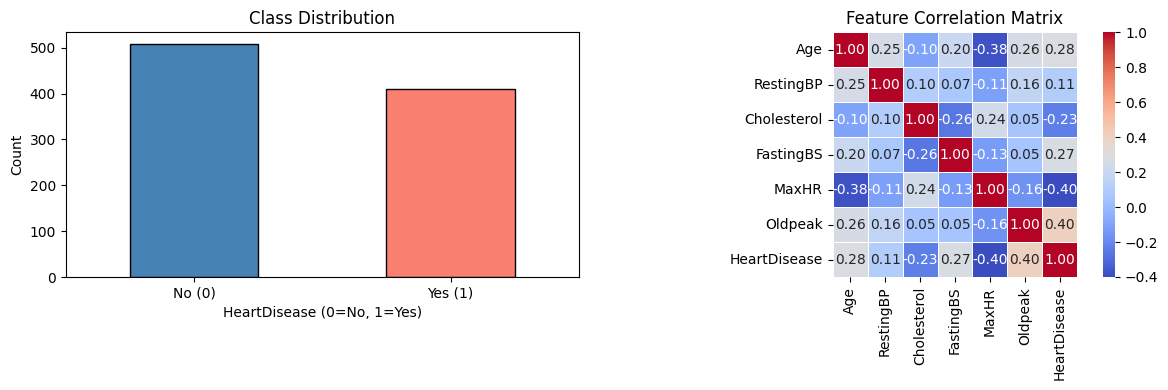

In [4]:
# Check for Missing Values 
print("Missing values per column:")
print(df.isnull().sum())

# Class Distribution 
print("\nClass Distribution (HeartDisease):")
print(df['HeartDisease'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['HeartDisease'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('HeartDisease (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

# Feature correlation heatmap placeholder (numerical only)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

### Identify Categorical vs Numerical Columns

In [5]:
target_col = 'HeartDisease'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:  ", numerical_cols)

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical columns:   ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


### One-Hot Encode Categorical Features

In [6]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Shape before encoding: ", df.shape)
print("Shape after encoding: ", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Shape before encoding:  (918, 12)
Shape after encoding:  (918, 21)
Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### Separate Features and Target

In [7]:
X = df_encoded.drop(columns=[target_col]).values.astype(float)
y = df_encoded[target_col].values.astype(int)

feature_names = df_encoded.drop(columns=[target_col]).columns.tolist()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance — 0:", np.sum(y==0), "  1:", np.sum(y==1))

X shape: (918, 20)
y shape: (918,)
Class balance — 0: 410   1: 508


### Train/Validation/Test Split (70%/10%/20%) 

Split         Samples  % Total   No Disease (0)  Heart Disease (1)
-----------------------------------------------------------------
Train             642    69.9%      287 (44.7%)        355 (55.3%)
Validation         92    10.0%       41 (44.6%)         51 (55.4%)
Test              184    20.0%       82 (44.6%)        102 (55.4%)


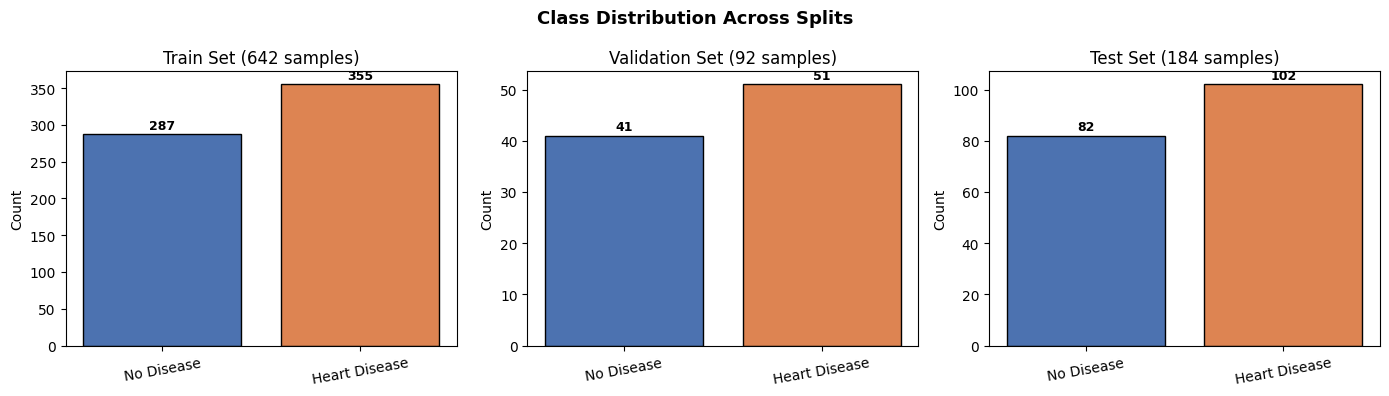

In [8]:
# First split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Then split remaining 80% into 70% train + 10% val  → 10/80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=RANDOM_SEED, stratify=y_trainval
)

#  Summary Table 
total  = len(X)
splits = {
    'Train'     : (X_train, y_train),
    'Validation': (X_val,   y_val),
    'Test'      : (X_test,  y_test),
}

print(f"{'Split':<12} {'Samples':>8} {'% Total':>8}  {'No Disease (0)':>15} {'Heart Disease (1)':>18}")
print('-' * 65)
for name, (X_s, y_s) in splits.items():
    y_series = pd.Series(y_s)
    counts   = y_series.value_counts().sort_index()
    pcts     = y_series.value_counts(normalize=True).sort_index() * 100
    c0 = f"{counts.get(0,0):,} ({pcts.get(0,0):.1f}%)"
    c1 = f"{counts.get(1,0):,} ({pcts.get(1,0):.1f}%)"
    print(f"{name:<12} {len(X_s):>8,} {len(X_s)/total*100:>7.1f}%  {c0:>15} {c1:>18}")

#  Visual Bar Chart 
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ['#4C72B0', '#DD8452']
for ax, (name, (X_s, y_s)) in zip(axes, splits.items()):
    y_series = pd.Series(y_s)
    counts   = y_series.value_counts().sort_index()
    bars = ax.bar(['No Disease', 'Heart Disease'], counts.values, color=colors, edgecolor='black')
    ax.set_title(f'{name} Set ({len(X_s):,} samples)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=10)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(counts.values)*0.01,
                f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Standardization(Numerical only)

Feature scaling complete (numerical columns only).
Scaled columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Train mean (should be ~0): [ 0.  0.  0.  0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1.]


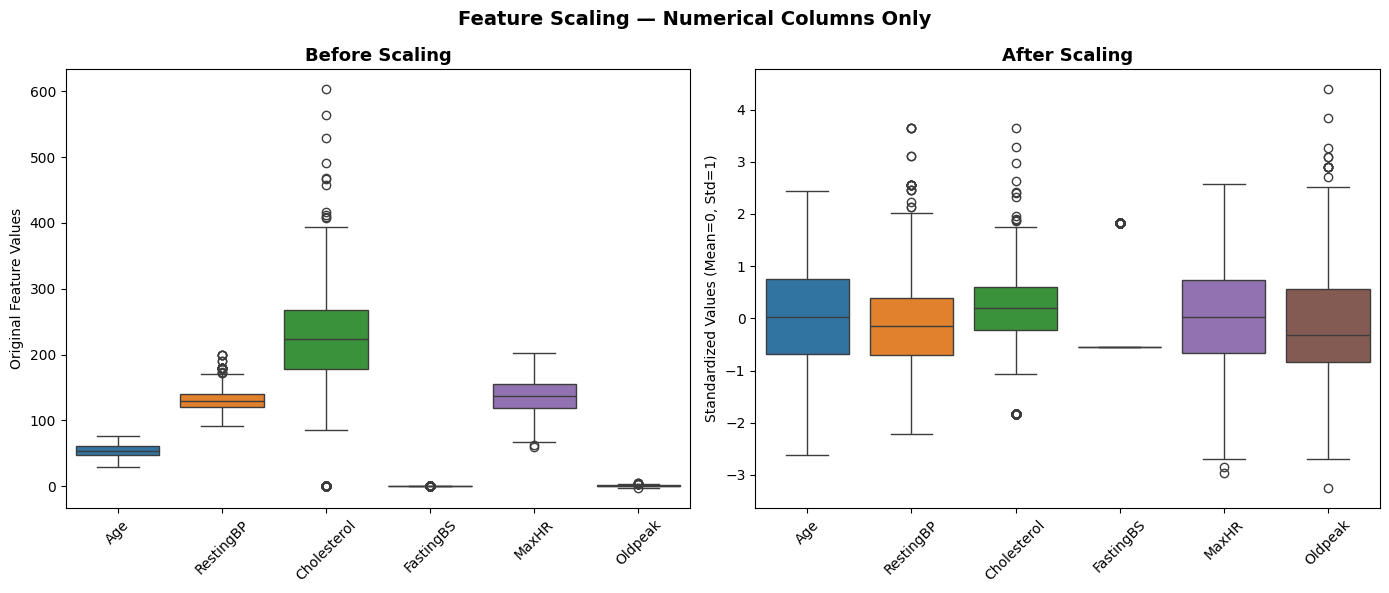

In [9]:
# Fit scaler ONLY on training set to prevent data leakage
# Scale ONLY numerical columns — one-hot encoded columns are already binary (0/1)
num_feature_indices = [feature_names.index(c) for c in numerical_cols]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[:, num_feature_indices] = scaler.fit_transform(X_train[:, num_feature_indices])
X_val_scaled  [:, num_feature_indices] = scaler.transform(X_val  [:, num_feature_indices])
X_test_scaled [:, num_feature_indices] = scaler.transform(X_test [:, num_feature_indices])

#  Verification 
print("Feature scaling complete (numerical columns only).")
print("Scaled columns:", numerical_cols)
print("Train mean (should be ~0):", X_train_scaled[:, num_feature_indices].mean(axis=0).round(4))
print("Train std  (should be ~1):", X_train_scaled[:, num_feature_indices].std(axis=0).round(4))

# Before / After Scaling Boxplots
before_df = pd.DataFrame(X_train[:, num_feature_indices], columns=numerical_cols)
after_df  = pd.DataFrame(X_train_scaled[:, num_feature_indices], columns=numerical_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=before_df, ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Original Feature Values')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=after_df, ax=axes[1])
axes[1].set_title('After Scaling', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Standardized Values (Mean=0, Std=1)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Scaling — Numerical Columns Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Defining evaluation helpers that will be reused for all three models.

In [10]:
def evaluate_model(name, y_true, y_pred):
    """
    Prints Accuracy, F1-Score and plots Confusion Matrix for a given model.
    Returns (accuracy, f1) for comparison table.
    """
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='binary')
    cm  = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1-Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Heart Disease','Heart Disease']))

    # ── Confusion Matrix Plot ────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted: No','Predicted: Yes'],
                yticklabels=['Actual: No','Actual: Yes'],
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return acc, f1

print("evaluate_model() helper defined.")

evaluate_model() helper defined.


---
## Section 3: Model 1 — Decision Tree (From Scratch)


Splitting continues until:
- Maximum depth is reached, **or**
- A node has fewer than `min_samples_split` samples, **or**
- All samples in a node belong to the same class (pure node).

In [12]:
class Node:
    """
    feature_idx   : index of the feature used for splitting (None for leaf)
    threshold     : threshold value for the split (None for leaf)
    left          : left child Node  (X[:, feature_idx] <= threshold)
    right         : right child Node (X[:, feature_idx] >  threshold)
    value         : class prediction (set only for leaf nodes)
    """
    def __init__(self, feature_idx=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold   = threshold
        self.left        = left
        self.right       = right
        self.value       = value   

    def is_leaf(self):
        return self.value is not None


class DecisionTree:

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.root              = None

    # Entropy 
    def _entropy(self , y):
        n = len(y)
        if n == 0:
            return 0.0
        counts = np.bincount(y)
        probs  = counts[counts > 0] / n          # avoid log(0)
        return -np.sum(probs * np.log2(probs))
    
    def _weighted_entropy(self, y, w):
        total = w.sum()
        if total == 0:
            return 0.0
        classes = np.unique(y)
        entropy = 0.0
        for c in classes:
            p = w[y == c].sum() / total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy
    

    # Information Gain 
    def _information_gain(self, y, y_l, y_r, w=None, w_l=None, w_r=None):
        if w is None:
            # Standard unweighted IG
            n, nl, nr = len(y), len(y_l), len(y_r)
            if nl == 0 or nr == 0:
                return 0.0
            return (self._entropy(y)
                    - (nl/n) * self._entropy(y_l)
                    - (nr/n) * self._entropy(y_r))
        else:
            # Weighted IG — proportions are sum-of-weights, not counts
            wt = w.sum()
            wl = w_l.sum()
            wr = w_r.sum()
            if wl == 0 or wr == 0:
                return 0.0
            return (self._weighted_entropy(y, w)
                    - (wl/wt) * self._weighted_entropy(y_l, w_l)
                    - (wr/wt) * self._weighted_entropy(y_r, w_r))

    #Best Split 
    def _best_split(self, X, y, w=None):
        best_gain, best_feat, best_thresh = -1, None, None
        for feat in range(X.shape[1]):
            uniq       = np.unique(X[:, feat])
            thresholds = (uniq[:-1] + uniq[1:]) / 2
            for thresh in thresholds:
                mask = X[:, feat] <= thresh
                y_l, y_r = y[mask], y[~mask]
                # min_samples_leaf check (count-based, not weight-based)
                if len(y_l) < self.min_samples_leaf or len(y_r) < self.min_samples_leaf:
                    continue
                if w is not None:
                    w_l, w_r = w[mask], w[~mask]
                    gain = self._information_gain(y, y_l, y_r, w, w_l, w_r)
                else:
                    gain = self._information_gain(y, y_l, y_r)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        return best_feat, best_thresh

    # Majority Vote 
    def _majority_class(self , y, w=None):
        if w is None:
            return Counter(y).most_common(1)[0][0]
        
        # Weighted majority: sum weights per class, pick argmax
        classes      = np.unique(y)
        class_weights = {c: w[y == c].sum() for c in classes}
        return max(class_weights, key=class_weights.get)

    # Recursive Tree Builder
    def _build_tree(self, X, y, w=None, depth=0):
        n_samples = len(y)
        if (n_samples < self.min_samples_split
                or (self.max_depth is not None and depth >= self.max_depth)
                or len(np.unique(y)) == 1):
            return Node(value=self._majority_class(y, w))

        feat, thresh = self._best_split(X, y, w)
        if feat is None:
            return Node(value=self._majority_class(y, w))

        mask  = X[:, feat] <= thresh
        w_l   = w[mask]  if w is not None else None
        w_r   = w[~mask] if w is not None else None
        left  = self._build_tree(X[mask],  y[mask],  w_l, depth + 1)
        right = self._build_tree(X[~mask], y[~mask], w_r, depth + 1)
        return Node(feature_idx=feat, threshold=thresh, left=left, right=right)

    
    def fit(self, X, y, sample_weight=None):
        w = None
        if sample_weight is not None:
            w = np.array(sample_weight, dtype=float)
            w = w / w.sum()   # normalise so weights sum to 1
        self.root = self._build_tree(X, y, w, depth=0)
        return self

    def _predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])



print("DecisionTree class defined successfully.")

DecisionTree class defined successfully.


### Hyperparameter Tuning — Decision Tree

We sweep `max_depth`, `min_samples_split`, and `min_samples_leaf` values on the **validation set** to find the best tree complexity.

In [58]:
import itertools
import warnings
warnings.filterwarnings('ignore')

param_grid = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 3, 5, 10, 15],
}

all_combos = list(itertools.product(
    param_grid['max_depth'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf']
))

print(f"Total combinations to evaluate: {len(all_combos)}")
print(f"Parameters: max_depth × min_samples_split × min_samples_leaf\n")

best_acc   = -1
best_params = None
grid_results = []

for depth, mss, msl in all_combos:
    # Guard: min_samples_leaf must be < min_samples_split (otherwise no split ever happens)
    if msl >= mss and mss > 2:
        pass  # still valid but tree may be very shallow — let it run
    dt   = DecisionTree(max_depth=depth, min_samples_split=mss, min_samples_leaf=msl)
    dt.fit(X_train_scaled, y_train)
    preds = dt.predict(X_val_scaled)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='binary')
    grid_results.append({'max_depth': depth, 'min_samples_split': mss,
                         'min_samples_leaf': msl, 'val_acc': acc, 'val_f1': f1})
    if acc > best_acc:
        best_acc    = acc
        best_params = {'max_depth': depth, 'min_samples_split': mss, 'min_samples_leaf': msl}

df_grid = pd.DataFrame(grid_results).sort_values('val_acc', ascending=False)

print("Top 10 combinations by Validation Accuracy:")
print(df_grid.head(10).to_string(index=False))
print(f"\n{'='*60}")
print(f"✔ Best Parameters Found:")
for k, v in best_params.items():
    print(f"   {k:>22} = {v}")
print(f"   {'val_accuracy':>22} = {best_acc*100:.2f}%")
print(f"{'='*60}")

best_depth = best_params['max_depth']
best_mss   = best_params['min_samples_split']
best_msl   = best_params['min_samples_leaf']


Total combinations to evaluate: 120
Parameters: max_depth × min_samples_split × min_samples_leaf

Top 10 combinations by Validation Accuracy:
 max_depth  min_samples_split  min_samples_leaf  val_acc   val_f1
       5.0                  2                10 0.858696 0.873786
       5.0                 10                15 0.858696 0.876190
       5.0                 20                10 0.858696 0.873786
       5.0                 20                15 0.858696 0.876190
       5.0                 10                10 0.858696 0.873786
       5.0                  5                15 0.858696 0.876190
       5.0                  5                10 0.858696 0.873786
       5.0                  2                15 0.858696 0.876190
       7.0                  2                15 0.858696 0.876190
       7.0                  5                15 0.858696 0.876190

✔ Best Parameters Found:
                max_depth = 5
        min_samples_split = 2
         min_samples_leaf = 10
             va

### Train Final Decision Tree and Evaluate on Test Set

Training final Decision Tree:
  max_depth         = 5
  min_samples_split = 2
  min_samples_leaf  = 10


Model: Decision Tree (Scratch)
  Accuracy : 84.24%
  F1-Score : 0.8585

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.82      0.82        82
   Heart Disease       0.85      0.86      0.86       102

        accuracy                           0.84       184
       macro avg       0.84      0.84      0.84       184
    weighted avg       0.84      0.84      0.84       184



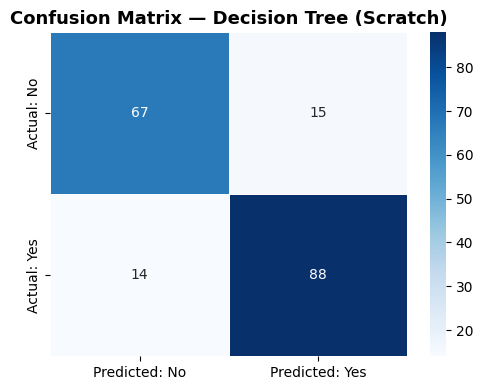

In [70]:
#Train Final Decision Tree with Best Hyperparameters 
print(f"Training final Decision Tree:")
print(f"  max_depth         = {best_depth}")
print(f"  min_samples_split = {best_mss}")
print(f"  min_samples_leaf  = {best_msl}\n")

dt_final = DecisionTree(
    max_depth=best_depth,
    min_samples_split=best_mss,
    min_samples_leaf=best_msl
)
dt_final.fit(X_train_scaled, y_train)

# Predict on Test Set 
y_pred_dt = dt_final.predict(X_test_scaled)

# Evaluate 
acc_dt, f1_dt = evaluate_model('Decision Tree (Scratch)', y_test, y_pred_dt)

---
## Section 4: Model 2 — Bagging Ensemble 


In [60]:
class BaggingClassifier:
    def __init__(self, n_estimators=20,
                 max_samples=1.0,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 random_state=42):
        self.n_estimators      = n_estimators
        self.max_samples       = max_samples
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.random_state      = random_state
        self.trees             = []

    # Bootstrap Sampling
    def _bootstrap_sample(self, X, y, rng):
        n           = X.shape[0]
        sample_size = max(1, int(self.max_samples * n))
        indices     = rng.choice(n, size=sample_size, replace=True)
        return X[indices], y[indices]

    # Training 
    def fit(self, X, y):
        self.trees = []
        rng        = np.random.RandomState(self.random_state)
        for _ in range(self.n_estimators):
            X_boot, y_boot = self._bootstrap_sample(X, y, rng)
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        return self

    # Prediction 
    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])  
        return np.array([
            Counter(votes).most_common(1)[0][0]
            for votes in all_preds.T
        ])


print("BaggingClassifier defined — all 5 parameters will be tuned via grid search.")


BaggingClassifier defined — all 5 parameters will be tuned via grid search.


### Hyperparameter Tuning - Bagging ensemble



| Parameter | Role | Values to search |
|---|---|---|
| `n_estimators` | How many bootstrap trees | 10, 30, 50|
| `max_samples` | Fraction of data per bootstrap | 0.6, 0.8 |
| `max_depth` | Tree depth (None = fully grown) | 5, 10|
| `min_samples_split` | Min samples to split a node | 2, 5, 10 |
| `min_samples_leaf` | Min samples per leaf | 1, 3, 5 |

Total combinations: **3 × 2 × 2 × 3 × 3 = 108**  
Each is evaluated on the validation set. The best combination is used to train the final model.

In [61]:
bag_param_grid = {
    'n_estimators'     : [10 , 30 ,50],
    'max_samples'      : [0.6 , 0.8],
    'max_depth'        : [5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 3, 5],
}

all_combos = list(itertools.product(
    bag_param_grid['n_estimators'],
    bag_param_grid['max_samples'],
    bag_param_grid['max_depth'],
    bag_param_grid['min_samples_split'],
    bag_param_grid['min_samples_leaf'],
))

print(f"Total combinations: {len(all_combos)}")
print(f"Grid: n_estimators({len(bag_param_grid['n_estimators'])}) x "
      f"max_samples({len(bag_param_grid['max_samples'])}) x "
      f"max_depth({len(bag_param_grid['max_depth'])}) x "
      f"min_samples_split({len(bag_param_grid['min_samples_split'])}) x "
      f"min_samples_leaf({len(bag_param_grid['min_samples_leaf'])})\n")


bag_results  = []
best_acc_bag = -1
best_params_bag = {}

for i, (n_est, ms, depth, mss, msl) in enumerate(all_combos):
    bag = BaggingClassifier(
        n_estimators=n_est,
        max_samples=ms,
        max_depth=depth,
        min_samples_split=mss,
        min_samples_leaf=msl,
        random_state=RANDOM_SEED
    )
    bag.fit(X_train_scaled, y_train)
    preds = bag.predict(X_val_scaled)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='binary')

    bag_results.append({
        'n_estimators'     : n_est,
        'max_samples'      : ms,
        'max_depth'        : depth,
        'min_samples_split': mss,
        'min_samples_leaf' : msl,
        'val_acc'          : acc,
        'val_f1'           : f1,
    })

    if acc > best_acc_bag or (acc == best_acc_bag and f1 > best_params_bag.get('val_f1', 0)):
        best_acc_bag    = acc
        best_params_bag = bag_results[-1].copy()

    if (i + 1) % 50 == 0:
        print(f" Evaluated {i+1}/{len(all_combos)} combinations...")

df_bag_grid = pd.DataFrame(bag_results).sort_values(
    ['val_acc', 'val_f1'], ascending=False
).reset_index(drop=True)

# Print Top 15 results 
print("\nTop 15 combinations by Validation Accuracy:")
print("=" * 78)
print(f"{'#':>3} | {'n_est':>5} | {'ms':>4} | {'depth':>5} | {'mss':>3} | {'msl':>3} | {'Val Acc':>8} | {'Val F1':>7} ")
print("-" * 78)
for idx, row in df_bag_grid.head(15).iterrows():
    depth_str = str(int(row['max_depth'])) if row['max_depth'] is not None else 'None'
    marker    = ' ✔' if idx == 0 else ''
    print(f"  {idx+1:>2} | {int(row['n_estimators']):>5} | {row['max_samples']:>4.1f} | "
          f"{depth_str:>5} | {int(row['min_samples_split']):>3} | {int(row['min_samples_leaf']):>3} | "
          f"{row['val_acc']*100:>7.2f}% | {row['val_f1']:>7.4f} ")
print("=" * 78)

# Store best params
best_n_bag   = best_params_bag['n_estimators']
best_ms_bag  = best_params_bag['max_samples']
best_dep_bag = best_params_bag['max_depth']
best_mss_bag = best_params_bag['min_samples_split']
best_msl_bag = best_params_bag['min_samples_leaf']

depth_label = str(best_dep_bag) if best_dep_bag is not None else 'None'
print(f"\nBest Bagging configuration:")
print(f"   n_estimators      = {best_n_bag}")
print(f"   max_samples       = {best_ms_bag}")
print(f"   max_depth         = {depth_label}")
print(f"   min_samples_split = {best_mss_bag}")
print(f"   min_samples_leaf  = {best_msl_bag}")
print(f"   Val Accuracy      = {best_acc_bag*100:.2f}%")
print("=" * 78)



Total combinations: 108
Grid: n_estimators(3) x max_samples(2) x max_depth(2) x min_samples_split(3) x min_samples_leaf(3)

 Evaluated 50/108 combinations...
 Evaluated 100/108 combinations...

Top 15 combinations by Validation Accuracy:
  # | n_est |   ms | depth | mss | msl |  Val Acc |  Val F1 
------------------------------------------------------------------------------
   1 |    50 |  0.6 |    10 |   2 |   5 |   86.96% |  0.8824 
   2 |    50 |  0.6 |    10 |   5 |   5 |   86.96% |  0.8824 
   3 |    50 |  0.6 |    10 |  10 |   5 |   86.96% |  0.8824 
   4 |    50 |  0.8 |    10 |  10 |   3 |   86.96% |  0.8824 
   5 |    30 |  0.8 |    10 |   2 |   1 |   85.87% |  0.8762 
   6 |    50 |  0.6 |    10 |  10 |   3 |   85.87% |  0.8762 
   7 |    30 |  0.6 |    10 |   2 |   1 |   85.87% |  0.8738 
   8 |    30 |  0.6 |    10 |   5 |   1 |   85.87% |  0.8738 
   9 |    30 |  0.6 |    10 |  10 |   1 |   85.87% |  0.8738 
  10 |    30 |  0.8 |    10 |   2 |   3 |   85.87% |  0.8738 
  

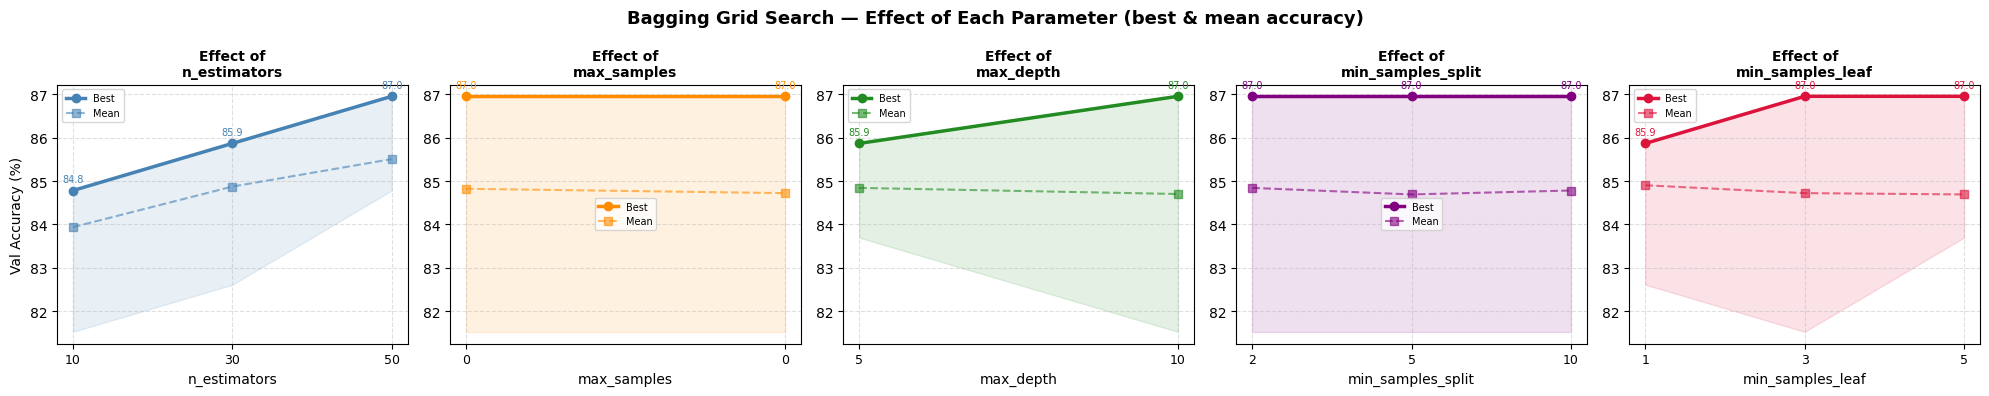

In [62]:
# Effect of each parameter individually 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

param_info = [
    ('n_estimators',      'n_estimators',       'steelblue'),
    ('max_samples',       'max_samples',         'darkorange'),
    ('max_depth',         'max_depth',           'forestgreen'),
    ('min_samples_split', 'min_samples_split',   'purple'),
    ('min_samples_leaf',  'min_samples_leaf',    'crimson'),
]

for ax, (col, label, color) in zip(axes, param_info):
    vals     = sorted(df_bag_grid[col].unique(),
                      key=lambda x: (x is None, x))
    best_acc_per_val = [df_bag_grid[df_bag_grid[col]==v]['val_acc'].max() for v in vals]
    mean_acc_per_val = [df_bag_grid[df_bag_grid[col]==v]['val_acc'].mean() for v in vals]
    xlabels  = [str(int(v)) if v is not None else 'None' for v in vals]

    ax.plot(range(len(vals)), [a*100 for a in best_acc_per_val],
            marker='o', color=color, linewidth=2.5, label='Best')
    ax.plot(range(len(vals)), [a*100 for a in mean_acc_per_val],
            marker='s', color=color, linewidth=1.5, linestyle='--',
            alpha=0.6, label='Mean')
    ax.fill_between(range(len(vals)),
        [df_bag_grid[df_bag_grid[col]==v]['val_acc'].min()*100 for v in vals],
        [a*100 for a in best_acc_per_val],
        alpha=0.12, color=color)
    for i, (xl, ba) in enumerate(zip(xlabels, best_acc_per_val)):
        ax.annotate(f'{ba*100:.1f}', (i, ba*100),
                    textcoords='offset points', xytext=(0, 6),
                    ha='center', fontsize=7, color=color)

    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Val Accuracy (%)' if ax == axes[0] else '')
    ax.set_title(f'Effect of\n{label}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Bagging Grid Search — Effect of Each Parameter (best & mean accuracy)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




### Train Final Bagging Model and Evaluate on Test Set


Final Bagging configuration (all params tuned on validation set):
  n_estimators      = 50
  max_samples       = 0.6
  max_depth         = 10
  min_samples_split = 2
  min_samples_leaf  = 5


Model: Bagging Ensemble (Scratch)
  Accuracy : 84.78%
  F1-Score : 0.8654

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.85      0.80      0.82        82
   Heart Disease       0.85      0.88      0.87       102

        accuracy                           0.85       184
       macro avg       0.85      0.84      0.85       184
    weighted avg       0.85      0.85      0.85       184



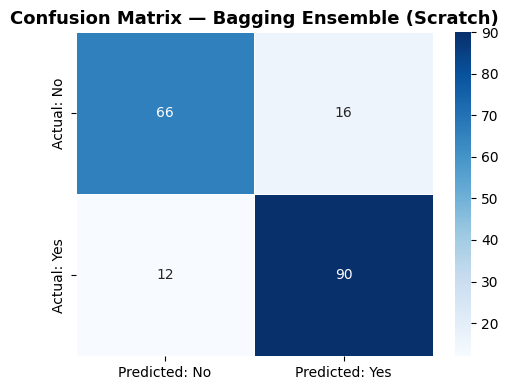


── Test Set Comparison ──
  Single Decision Tree : Acc=84.24%  F1=0.8585
  Bagging Ensemble     : Acc=84.78%  F1=0.8654
  Improvement          : +0.54% accuracy


In [63]:
#Train Final Bagging Model with Best Hyperparameters 
depth_label = str(best_dep_bag) if best_dep_bag is not None else 'None'
print("Final Bagging configuration (all params tuned on validation set):")
print(f"  n_estimators      = {best_n_bag}")
print(f"  max_samples       = {best_ms_bag}")
print(f"  max_depth         = {depth_label}")
print(f"  min_samples_split = {best_mss_bag}")
print(f"  min_samples_leaf  = {best_msl_bag}")
print()

bag_final = BaggingClassifier(
    n_estimators=best_n_bag,
    max_samples=best_ms_bag,
    max_depth=best_dep_bag,
    min_samples_split=best_mss_bag,
    min_samples_leaf=best_msl_bag,
    random_state=RANDOM_SEED
)
bag_final.fit(X_train_scaled, y_train)

# Predict on Test Set 
y_pred_bag = bag_final.predict(X_test_scaled)

#  Evaluate 
acc_bag, f1_bag = evaluate_model('Bagging Ensemble (Scratch)', y_test, y_pred_bag)

#  Compare to single DT on test set 
print("\n── Test Set Comparison ──")
print(f"  Single Decision Tree : Acc={acc_dt*100:.2f}%  F1={f1_dt:.4f}")
print(f"  Bagging Ensemble     : Acc={acc_bag*100:.2f}%  F1={f1_bag:.4f}")
delta = (acc_bag - acc_dt) * 100
sign  = '+' if delta >= 0 else ''
print(f"  Improvement          : {sign}{delta:.2f}% accuracy")


---
## Section 5: Model 3 — AdaBoost Ensemble (From Scratch)

### Theory

**AdaBoost (Adaptive Boosting)** builds an ensemble **sequentially**, where each new weak learner focuses on the mistakes of previous ones:

1. Initialize sample weights uniformly: $w_i = \frac{1}{N}$
2. For each round $t = 1, \ldots, T$:
   - Train weak learner $h_t$ **directly on the weighted dataset**
   - Compute weighted error: $\epsilon_t = \sum_i w_i \cdot \mathbf{1}[h_t(x_i) \neq y_i]$
   - Compute learner weight: $\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$
   - Update sample weights: $w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}$, then normalise
3. Final prediction: $H(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$

> **Note:** AdaBoost requires labels $\{-1, +1\}$. We convert internally.






In [52]:
class AdaBoostClassifier:

    def __init__(self, n_estimators=50, stump_depth=1):
        self.n_estimators = n_estimators
        self.stump_depth  = stump_depth
        self.alphas       = []    # learner weights α_t
        self.stumps       = []    # weak learners h_t

    
    def Convert_to_adaboost_labels(self, y):
        return np.where(y == 1, 1, -1).astype(float)

    
    def Convert_from_adaboost_labels(self, y):
        return np.where(y >= 0, 1, 0).astype(int)

    def fit(self, X, y):
        y_ab = self.Convert_to_adaboost_labels(y)   
        n    = X.shape[0]
        weights = np.ones(n) / n

        self.alphas  = []
        self.stumps  = []

        for t in range(self.n_estimators):
            
            # Train weak learner 
            stump = DecisionTree(max_depth=self.stump_depth, min_samples_split=2)
            stump.fit(X,self.Convert_from_adaboost_labels(y_ab),sample_weight=weights) 

            # Predictions on FULL training set 
            preds_01 = stump.predict(X)           # 0/1 labels
            preds_ab = self.Convert_to_adaboost_labels(preds_01)  # -1/+1

            # Weighted Error 
            incorrect = (preds_ab != y_ab).astype(float)
            eps = np.dot(weights, incorrect)    
            eps = np.clip(eps, 1e-10, 1 - 1e-10)  # avoid log(0)
            if eps >= 0.5:
                print(f"[AdaBoost] Early stop at round {t+1}: eps={eps:.4f} >= 0.5")
                break

            # Learner Weight
            alpha = 0.5 * np.log((1 - eps) / eps)

            # Update Sample Weights 
            weights = weights * np.exp(-alpha * y_ab * preds_ab)
            weights /= weights.sum()  # normalise

            self.alphas.append(alpha)
            self.stumps.append(stump)

        return self

    def predict(self, X):
        # Weighted sum of weak learner predictions
        aggregate = np.zeros(X.shape[0])
        for alpha, stump in zip(self.alphas, self.stumps):
            preds_01 = stump.predict(X)
            preds_ab = self.Convert_to_adaboost_labels(preds_01)
            aggregate += alpha * preds_ab
        # Convert sign to 0/1 labels
        return self.Convert_from_adaboost_labels(np.sign(aggregate))


print("AdaBoostClassifier class defined successfully.")
print("Tunable parameters: n_estimators, stump_depth")

AdaBoostClassifier class defined successfully.
Tunable parameters: n_estimators, stump_depth


### Hyperparameter Tuning — AdaBoost

| Parameter | Description | Values |
|---|---|---|
| `n_estimators` | Number of boosting rounds | 10, 25, 50, 75, 100 |
| `stump_depth` | Depth of each weak learner | 1 (stump), 2, 3 |

Total combinations: **5 × 3 = 15**

In [53]:
import itertools
import warnings
warnings.filterwarnings('ignore')

# Parameter Grid 
round_values = [10, 25, 50, 75, 100 ]
depth_values = [1,2,3]

all_combos_ada = list(itertools.product(round_values, depth_values))
print(f"Total combinations: {len(all_combos_ada)}  "
      f"(n_estimators × stump_depth = {len(round_values)} × {len(depth_values)})\n")

ada_results  = []
best_acc_ada = -1
best_params_ada = {}

print(f"{'n_est':>6} | {'depth':>5} | {'Val Acc':>9} | {'Val F1':>7} ")
print("-" * 62)

prev_depth = None
for n_est, depth in all_combos_ada:


    ada = AdaBoostClassifier(n_estimators=n_est, stump_depth=depth)
    ada.fit(X_train_scaled, y_train)
    preds = ada.predict(X_val_scaled)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='binary')

    ada_results.append({
        'n_estimators': n_est,
        'stump_depth' : depth,
        'val_acc'     : acc,
        'val_f1'      : f1,
    })

    if acc > best_acc_ada or (acc == best_acc_ada and f1 > best_params_ada.get('val_f1', 0)):
        best_acc_ada    = acc
        best_params_ada = ada_results[-1].copy()

    print(f"  {n_est:>4} | {depth:>5} | {acc*100:>8.2f}% | {f1:>7.4f}")

df_ada_grid = pd.DataFrame(ada_results).sort_values(
    ['val_acc', 'val_f1'], ascending=False
).reset_index(drop=True)

best_n_ada     = best_params_ada['n_estimators']
best_depth_ada = best_params_ada['stump_depth']

learner_name = {1: 'Decision Stump', 2: 'Shallow Tree (depth=2)', 3: 'Shallow Tree (depth=3)'}[best_depth_ada]
print(f"\n{'='*62}")
print(f" Best AdaBoost configuration:")
print(f"   n_estimators = {best_n_ada}")
print(f"   stump_depth  = {best_depth_ada}  ({learner_name})")
print(f"   Val Accuracy = {best_acc_ada*100:.2f}%")
print(f"   Val F1-Score = {best_params_ada['val_f1']:.4f}")
print(f"{'='*62}")


Total combinations: 15  (n_estimators × stump_depth = 5 × 3)

 n_est | depth |   Val Acc |  Val F1 
--------------------------------------------------------------
    10 |     1 |    83.70% |  0.8515
    10 |     2 |    80.43% |  0.8200
    10 |     3 |    85.87% |  0.8687
    25 |     1 |    83.70% |  0.8515
    25 |     2 |    79.35% |  0.8081
    25 |     3 |    85.87% |  0.8738
    50 |     1 |    82.61% |  0.8431
    50 |     2 |    79.35% |  0.8081
    50 |     3 |    86.96% |  0.8846
    75 |     1 |    82.61% |  0.8431
    75 |     2 |    82.61% |  0.8367
    75 |     3 |    86.96% |  0.8846
   100 |     1 |    82.61% |  0.8431
   100 |     2 |    82.61% |  0.8367
   100 |     3 |    88.04% |  0.8932

 Best AdaBoost configuration:
   n_estimators = 100
   stump_depth  = 3  (Shallow Tree (depth=3))
   Val Accuracy = 88.04%
   Val F1-Score = 0.8932


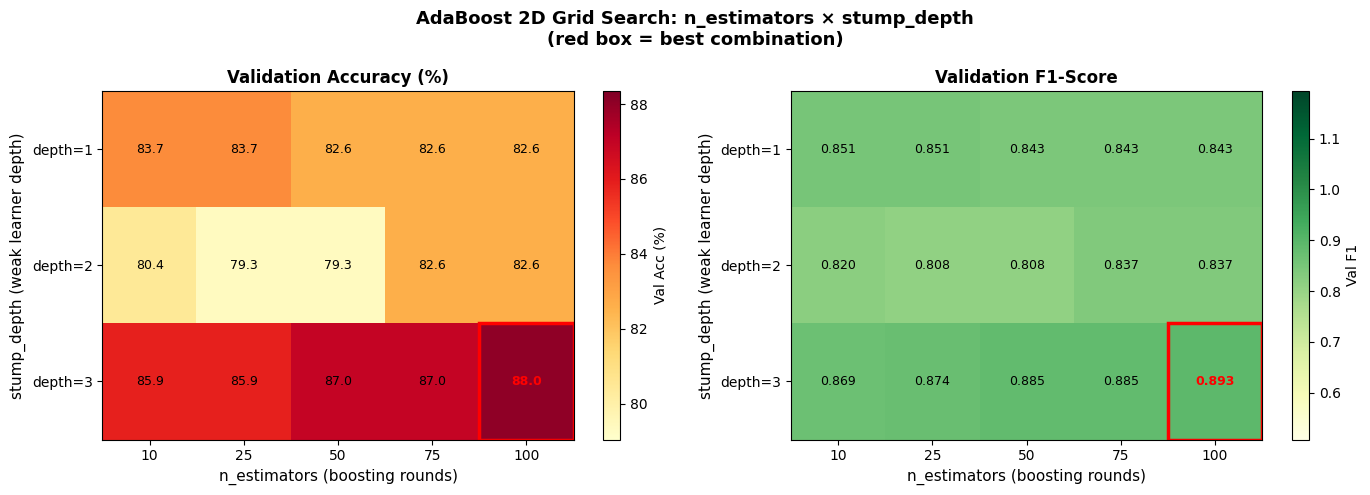

In [54]:
# ── Visualisation 1: Heatmap — n_estimators × stump_depth ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_matrix = np.array([
    [df_ada_grid[(df_ada_grid['n_estimators']==n) &
                 (df_ada_grid['stump_depth']==d)]['val_acc'].values[0] * 100
     for n in round_values]
    for d in depth_values
])
f1_matrix = np.array([
    [df_ada_grid[(df_ada_grid['n_estimators']==n) &
                 (df_ada_grid['stump_depth']==d)]['val_f1'].values[0]
     for n in round_values]
    for d in depth_values
])

for ax, matrix, cmap, fmt, title, cbar_lbl in [
    (axes[0], acc_matrix, 'YlOrRd', '.1f', 'Validation Accuracy (%)',  'Val Acc (%)'),
    (axes[1], f1_matrix,  'YlGn',   '.3f', 'Validation F1-Score',      'Val F1'),
]:
    im = ax.imshow(matrix, cmap=cmap, aspect='auto',
                   vmin=matrix.min()-0.3, vmax=matrix.max()+0.3)
    ax.set_xticks(range(len(round_values)))
    ax.set_xticklabels(round_values)
    ax.set_yticks(range(len(depth_values)))
    ax.set_yticklabels([f'depth={d}' for d in depth_values])
    ax.set_xlabel('n_estimators (boosting rounds)', fontsize=11)
    ax.set_ylabel('stump_depth (weak learner depth)', fontsize=11)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, label=cbar_lbl)
    for i, d in enumerate(depth_values):
        for j, n in enumerate(round_values):
            is_best = (n == best_n_ada and d == best_depth_ada)
            val = matrix[i, j]
            ax.text(j, i, f'{val:{fmt}}',
                    ha='center', va='center', fontsize=9,
                    fontweight='bold' if is_best else 'normal',
                    color='red' if is_best else 'black')
            if is_best:
                ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1,
                             fill=False, edgecolor='red', linewidth=2.5))

plt.suptitle('AdaBoost 2D Grid Search: n_estimators × stump_depth\n'
             '(red box = best combination)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




### Train Final AdaBoost Model and Evaluate on Test Set

Final AdaBoost configuration:
  n_estimators = 100   ← tuned on validation set
  stump_depth  = 3   ← tuned on validation set (Shallow Tree (depth=3))


Model: AdaBoost Ensemble (Scratch)
  Accuracy : 86.96%
  F1-Score : 0.8800

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.88      0.86        82
   Heart Disease       0.90      0.86      0.88       102

        accuracy                           0.87       184
       macro avg       0.87      0.87      0.87       184
    weighted avg       0.87      0.87      0.87       184



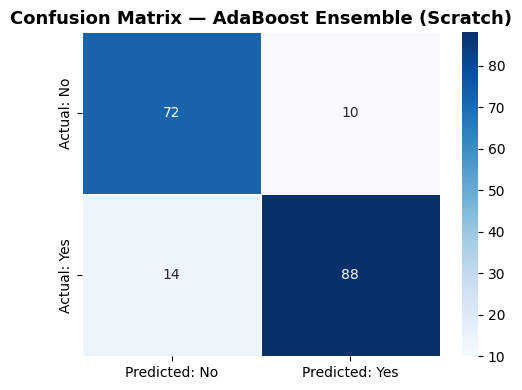

In [ ]:
#  Train Final AdaBoost Model with Best Hyperparameters 
learner_name = {1: 'Decision Stump',
                2: 'Shallow Tree (depth=2)',
                3: 'Shallow Tree (depth=3)'}[best_depth_ada]

print("Final AdaBoost configuration:")
print(f"  n_estimators = {best_n_ada}   ← tuned on validation set")
print(f"  stump_depth  = {best_depth_ada}   ← tuned on validation set ({learner_name})")
print()

ada_final = AdaBoostClassifier(
    n_estimators=best_n_ada,
    stump_depth=best_depth_ada
)
ada_final.fit(X_train_scaled, y_train)

#  Predict on Test Set 
y_pred_ada = ada_final.predict(X_test_scaled)

# Evaluate 
acc_ada, f1_ada = evaluate_model('AdaBoost Ensemble (Scratch)', y_test, y_pred_ada)


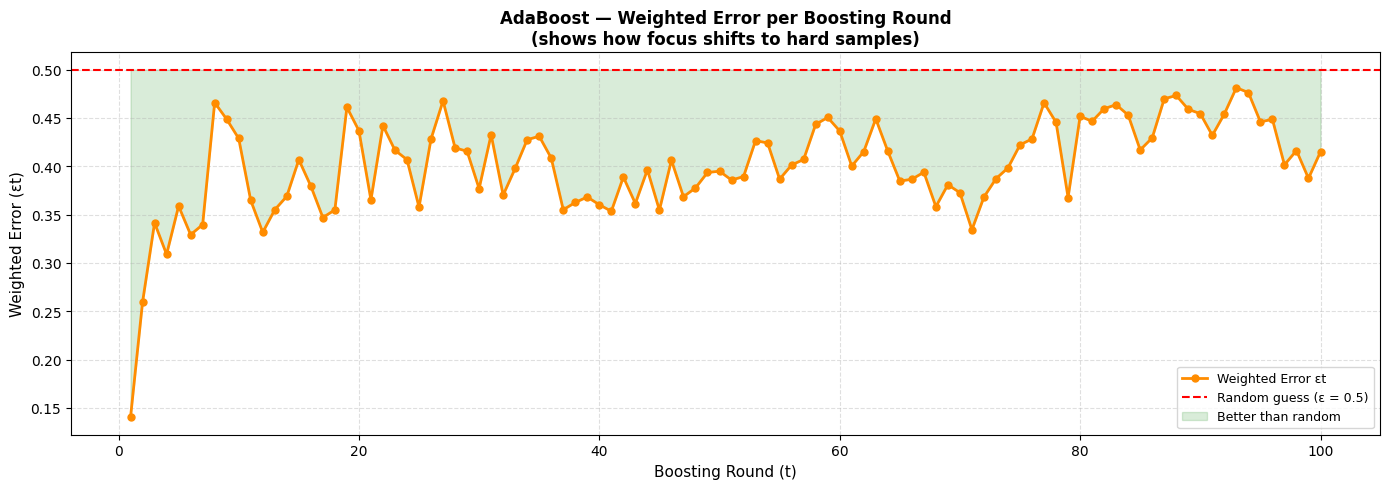

In [56]:
# ── Most Confused Class Analysis — AdaBoost ──────────────────────────────────

# 3. Per-class error bar chart
fig, ax = plt.subplots(1, 1, figsize=(14, 5))


# 4. Per-round weighted error plot
round_errors = []
n_train      = X_train_scaled.shape[0]
w_track      = np.ones(n_train) / n_train
y_ab_track   = np.where(y_train == 1, 1, -1).astype(float)

for stump, alpha in zip(ada_final.stumps, ada_final.alphas):
    preds_01 = stump.predict(X_train_scaled)
    preds_ab = np.where(preds_01 == 1, 1, -1).astype(float)
    incorrect = (preds_ab != y_ab_track).astype(float)
    eps = np.dot(w_track, incorrect)
    round_errors.append(eps)
    w_track = w_track * np.exp(-alpha * y_ab_track * preds_ab)
    w_track /= w_track.sum()

ax.plot(range(1, len(round_errors) + 1), round_errors,
        marker='o', color='darkorange', linewidth=2, markersize=5, label='Weighted Error εt')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random guess (ε = 0.5)')
ax.fill_between(range(1, len(round_errors) + 1), round_errors, 0.5,
                where=[e < 0.5 for e in round_errors],
                alpha=0.15, color='green', label='Better than random')
ax.set_xlabel('Boosting Round (t)', fontsize=11)
ax.set_ylabel('Weighted Error (εt)', fontsize=11)
ax.set_title('AdaBoost — Weighted Error per Boosting Round\n(shows how focus shifts to hard samples)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Section 6: Bonus — Random Forest 



In [64]:
class RandomForestTree(DecisionTree):

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None, random_state=42):
        super().__init__(max_depth=max_depth,
                         min_samples_split=min_samples_split,
                         min_samples_leaf=min_samples_leaf)
        self.max_features  = max_features
        self.random_state  = random_state
        self._node_counter = 0   # use this counter to change the random seed at every single node

    def _best_split(self, X, y, w=None): # Overrides DecisionTree._best_split().
        n_features_total = X.shape[1]
        n_features_try   = self.max_features or n_features_total

        # Unique RNG per node so each node picks different features
        rng = np.random.RandomState(self.random_state + self._node_counter)
        self._node_counter += 1

        # Sample feature indices WITHOUT replacement
        feature_indices = rng.choice(n_features_total,
                                     size=min(n_features_try, n_features_total),
                                     replace=False)

        best_gain, best_feat, best_thresh = -1, None, None

        for feat in feature_indices:          # only search sampled features
            uniq       = np.unique(X[:, feat])
            thresholds = (uniq[:-1] + uniq[1:]) / 2

            for thresh in thresholds:
                mask = X[:, feat] <= thresh
                y_l, y_r = y[mask], y[~mask]
                if len(y_l) < self.min_samples_leaf or len(y_r) < self.min_samples_leaf:
                    continue
                if w is not None:
                    w_l, w_r = w[mask], w[~mask]
                    gain = self._information_gain(y, y_l, y_r, w, w_l, w_r)
                else:
                    gain = self._information_gain(y, y_l, y_r)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh

        return best_feat, best_thresh

    def fit(self, X, y, sample_weight=None):
        self._node_counter = 0
        return super().fit(X, y, sample_weight=sample_weight)


class RandomForestClassifier:
   
    def __init__(self, n_estimators=100,
                 max_samples=1.0,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features='sqrt',
                 random_state=42):
        self.n_estimators      = n_estimators
        self.max_samples       = max_samples
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.random_state      = random_state
        self.trees             = []
        self.n_features_       = None   # set during fit
        self.max_features_int_ = None   # actual integer used

    def _resolve_max_features(self, p):
        if self.max_features == 'sqrt':
            return max(1, int(np.floor(np.sqrt(p))))
        return int(self.max_features)

    def _bootstrap_sample(self, X, y, rng):
        n           = X.shape[0]
        sample_size = max(1, int(self.max_samples * n))
        indices     = rng.choice(n, size=sample_size, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        self.trees             = []
        self.n_features_       = X.shape[1]
        self.max_features_int_ = self._resolve_max_features(self.n_features_)

        rng = np.random.RandomState(self.random_state)

        for i in range(self.n_estimators):
            X_boot, y_boot = self._bootstrap_sample(X, y, rng)

            # Each tree gets a unique seed so node-level feature sampling differs
            tree = RandomForestTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features_int_,
                random_state=self.random_state + i * 1000
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees]) 
        return np.array([
            Counter(votes).most_common(1)[0][0]
            for votes in all_preds.T
        ])



p_example = 20   # our dataset has 20 features
print("RandomForestClassifier and RandomForestTree defined.")
print(f"  Dataset has {p_example} features → max_features per split = floor(sqrt({p_example})) = {int(np.floor(np.sqrt(p_example)))}")
print(f"  Each split searches {int(np.floor(np.sqrt(p_example)))} out of {p_example} features")


RandomForestClassifier and RandomForestTree defined.
  Dataset has 20 features → max_features per split = floor(sqrt(20)) = 4
  Each split searches 4 out of 20 features


### 6.1 Hyperparameter Tuning — 5D Grid Search (same grid as Bagging)

We use the exact same grid as Bagging (**108 combinations**) so the comparison is fair:

| Parameter | Values |
|---|---|
| `n_estimators` | 10, 30, 50 |
| `max_samples` | 0.6, 0.8 |
| `max_depth` | 5, 10 |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 3, 5 |
| `max_features` | `'sqrt'` (fixed — defines RF) |


In [65]:
rf_param_grid = {
    'n_estimators'     : [10, 30, 50],
    'max_samples'      : [0.6, 0.8],
    'max_depth'        : [5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 3, 5],
}

all_rf_combos = list(itertools.product(
    rf_param_grid['n_estimators'],
    rf_param_grid['max_samples'],
    rf_param_grid['max_depth'],
    rf_param_grid['min_samples_split'],
    rf_param_grid['min_samples_leaf'],
))

# Show how many features will be sampled per split
p_total    = X_train_scaled.shape[1]
p_sqrt     = int(np.floor(np.sqrt(p_total)))
print(f"Total features p = {p_total}  →  max_features per split = sqrt({p_total}) = {p_sqrt}")
print(f"Total combinations: {len(all_rf_combos)}\n")

rf_results      = []
best_acc_rf     = -1
best_params_rf  = {}

for i, (n_est, ms, depth, mss, msl) in enumerate(all_rf_combos):
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_samples=ms,
        max_depth=depth,
        min_samples_split=mss,
        min_samples_leaf=msl,
        max_features='sqrt',
        random_state=RANDOM_SEED
    )
    rf.fit(X_train_scaled, y_train)
    preds = rf.predict(X_val_scaled)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='binary')

    rf_results.append({
        'n_estimators'     : n_est,
        'max_samples'      : ms,
        'max_depth'        : depth,
        'min_samples_split': mss,
        'min_samples_leaf' : msl,
        'val_acc'          : acc,
        'val_f1'           : f1,
    })

    if acc > best_acc_rf or (acc == best_acc_rf and f1 > best_params_rf.get('val_f1', 0)):
        best_acc_rf    = acc
        best_params_rf = rf_results[-1].copy()

    if (i + 1) % 50 == 0:
        print(f"  Evaluated {i+1}/{len(all_rf_combos)} combinations...")

df_rf_grid = pd.DataFrame(rf_results).sort_values(
    ['val_acc', 'val_f1'], ascending=False
).reset_index(drop=True)

# Print Top 15
print("\nTop 15 Random Forest combinations:")
print("=" * 80)
print(f"{'#':>3} | {'n_est':>5} | {'ms':>4} | {'depth':>5} | {'mss':>3} | {'msl':>3} | {'Val Acc':>8} | {'Val F1':>7} ")
print("-" * 80)
for idx, row in df_rf_grid.head(15).iterrows():
    depth_str = str(int(row['max_depth'])) if row['max_depth'] is not None else 'None'
    print(f"  {idx+1:>2} | {int(row['n_estimators']):>5} | {row['max_samples']:>4.1f} | "
          f"{depth_str:>5} | {int(row['min_samples_split']):>3} | {int(row['min_samples_leaf']):>3} | "
          f"{row['val_acc']*100:>7.2f}% | {row['val_f1']:>7.4f} ")
print("=" * 80)

best_n_rf   = best_params_rf['n_estimators']
best_ms_rf  = best_params_rf['max_samples']
best_dep_rf = best_params_rf['max_depth']
best_mss_rf = best_params_rf['min_samples_split']
best_msl_rf = best_params_rf['min_samples_leaf']
dep_rf_lbl  = str(best_dep_rf) if best_dep_rf is not None else 'None'

print(f"\n Best Random Forest configuration:")
print(f"   n_estimators      = {best_n_rf}")
print(f"   max_samples       = {best_ms_rf}")
print(f"   max_depth         = {dep_rf_lbl}")
print(f"   min_samples_split = {best_mss_rf}")
print(f"   min_samples_leaf  = {best_msl_rf}")
print(f"   max_features      = 'sqrt' → {p_sqrt} features per split (fixed)")
print(f"   Val Accuracy      = {best_acc_rf*100:.2f}%")
print("=" * 80)



Total features p = 20  →  max_features per split = sqrt(20) = 4
Total combinations: 108

  Evaluated 50/108 combinations...
  Evaluated 100/108 combinations...

Top 15 Random Forest combinations:
  # | n_est |   ms | depth | mss | msl |  Val Acc |  Val F1 
--------------------------------------------------------------------------------
   1 |    30 |  0.6 |    10 |  10 |   1 |   88.04% |  0.8911 
   2 |    30 |  0.6 |    10 |   2 |   3 |   86.96% |  0.8846 
   3 |    30 |  0.8 |    10 |   5 |   1 |   86.96% |  0.8846 
   4 |    50 |  0.6 |    10 |  10 |   1 |   86.96% |  0.8846 
   5 |    30 |  0.6 |    10 |   5 |   3 |   86.96% |  0.8824 
   6 |    50 |  0.8 |    10 |  10 |   1 |   86.96% |  0.8824 
   7 |    10 |  0.8 |    10 |   2 |   3 |   85.87% |  0.8738 
   8 |    30 |  0.6 |    10 |  10 |   3 |   85.87% |  0.8738 
   9 |    30 |  0.8 |    10 |  10 |   1 |   85.87% |  0.8738 
  10 |    50 |  0.6 |    10 |   2 |   3 |   85.87% |  0.8738 
  11 |    50 |  0.8 |    10 |   5 |   1 | 

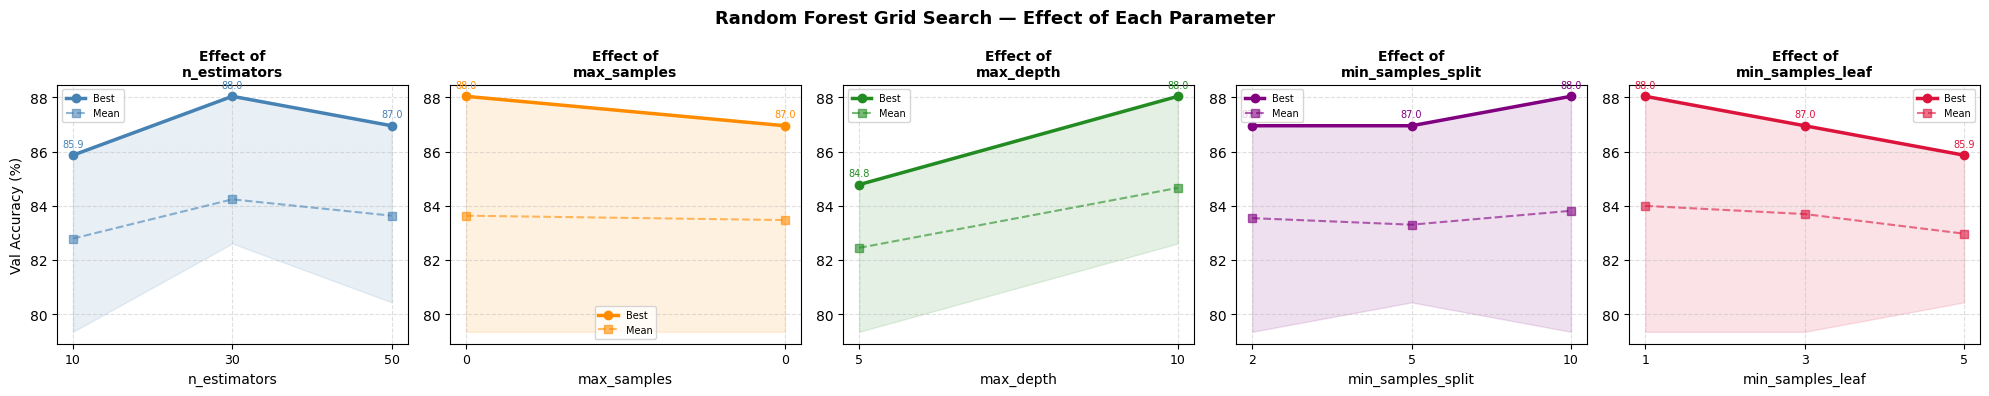

In [66]:

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
param_info = [
    ('n_estimators',      'steelblue'),
    ('max_samples',       'darkorange'),
    ('max_depth',         'forestgreen'),
    ('min_samples_split', 'purple'),
    ('min_samples_leaf',  'crimson'),
]
for ax, (col, color) in zip(axes, param_info):
    vals = sorted(df_rf_grid[col].unique(), key=lambda x: (x is None, x))
    best_acc_v = [df_rf_grid[df_rf_grid[col]==v]['val_acc'].max() for v in vals]
    mean_acc_v = [df_rf_grid[df_rf_grid[col]==v]['val_acc'].mean() for v in vals]
    xlabels    = [str(int(v)) if v is not None else 'None' for v in vals]
    ax.plot(range(len(vals)), [a*100 for a in best_acc_v],
            marker='o', color=color, linewidth=2.5, label='Best')
    ax.plot(range(len(vals)), [a*100 for a in mean_acc_v],
            marker='s', color=color, linewidth=1.5, linestyle='--', alpha=0.6, label='Mean')
    ax.fill_between(range(len(vals)),
        [df_rf_grid[df_rf_grid[col]==v]['val_acc'].min()*100 for v in vals],
        [a*100 for a in best_acc_v], alpha=0.12, color=color)
    for i, (xl, ba) in enumerate(zip(xlabels, best_acc_v)):
        ax.annotate(f'{ba*100:.1f}', (i, ba*100), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=7, color=color)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Val Accuracy (%)' if ax == axes[0] else '')
    ax.set_title(f'Effect of\n{col}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Random Forest Grid Search — Effect of Each Parameter',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 Train Final Random Forest and Evaluate on Test Set


Final Random Forest configuration:
  n_estimators      = 30
  max_samples       = 0.6
  max_depth         = 10
  min_samples_split = 10
  min_samples_leaf  = 1
  max_features      = 'sqrt' → 4 out of 20 features per split


Model: Random Forest (Scratch)
  Accuracy : 89.67%
  F1-Score : 0.9073

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.88      0.88        82
   Heart Disease       0.90      0.91      0.91       102

        accuracy                           0.90       184
       macro avg       0.90      0.89      0.90       184
    weighted avg       0.90      0.90      0.90       184



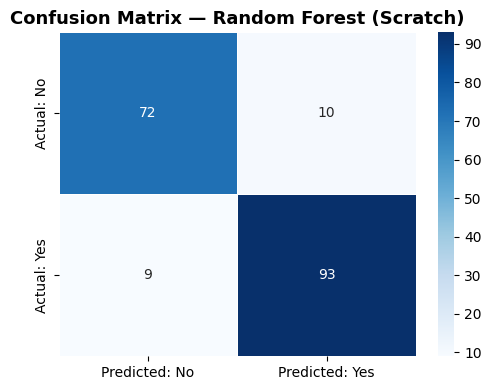

In [67]:
# ── Train Final Random Forest ─────────────────────────────────────────────────
dep_rf_lbl = str(best_dep_rf) if best_dep_rf is not None else 'None'
p_sqrt_final = int(np.floor(np.sqrt(X_train_scaled.shape[1])))

print("Final Random Forest configuration:")
print(f"  n_estimators      = {best_n_rf}")
print(f"  max_samples       = {best_ms_rf}")
print(f"  max_depth         = {dep_rf_lbl}")
print(f"  min_samples_split = {best_mss_rf}")
print(f"  min_samples_leaf  = {best_msl_rf}")
print(f"  max_features      = 'sqrt' → {p_sqrt_final} out of {X_train_scaled.shape[1]} features per split")
print()

rf_final = RandomForestClassifier(
    n_estimators=best_n_rf,
    max_samples=best_ms_rf,
    max_depth=best_dep_rf,
    min_samples_split=best_mss_rf,
    min_samples_leaf=best_msl_rf,
    max_features='sqrt',
    random_state=RANDOM_SEED
)
rf_final.fit(X_train_scaled, y_train)

# ── Predict on Test Set ───────────────────────────────────────────────────────
y_pred_rf = rf_final.predict(X_test_scaled)

# ── Evaluate ──────────────────────────────────────────────────────────────────
acc_rf, f1_rf = evaluate_model('Random Forest (Scratch)', y_test, y_pred_rf)



---
## Section 6: Comparative Evaluation

### Summary Table

In [72]:
# ── Summary Table — All 4 Models ────────────────────────────────────────────
results = pd.DataFrame({
    'Model'    : ['Decision Tree', 'Bagging Ensemble', 'AdaBoost Ensemble', 'Random Forest'],
    'Accuracy' : [f'{acc_dt*100:.2f}%',  f'{acc_bag*100:.2f}%',
                  f'{acc_ada*100:.2f}%', f'{acc_rf*100:.2f}%'],
    'F1-Score' : [f'{f1_dt:.4f}', f'{f1_bag:.4f}', f'{f1_ada:.4f}', f'{f1_rf:.4f}']
})

print("\n" + "="*56)
print("        FINAL MODEL COMPARISON — TEST SET")
print("="*56)
print(results.to_string(index=False))
print("="*56)



        FINAL MODEL COMPARISON — TEST SET
            Model Accuracy F1-Score
    Decision Tree   84.24%   0.8585
 Bagging Ensemble   84.78%   0.8654
AdaBoost Ensemble   86.96%   0.8800
    Random Forest   89.67%   0.9073


### Bar Chart Comparison

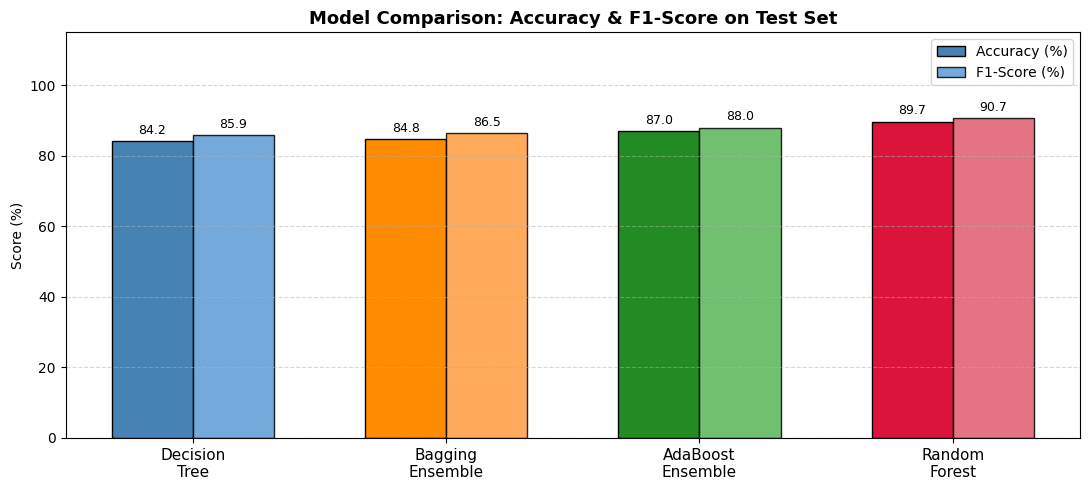

In [73]:
# ── Bar Chart: All 4 Models ───────────────────────────────────────────────────
model_names = ['Decision\nTree', 'Bagging\nEnsemble',
               'AdaBoost\nEnsemble', 'Random\nForest']
accs = [acc_dt*100, acc_bag*100, acc_ada*100, acc_rf*100]
f1s  = [f1_dt*100,  f1_bag*100,  f1_ada*100,  f1_rf*100]

x          = np.arange(len(model_names))
w          = 0.32
colors_acc = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
colors_f1  = ['#5b9bd5',   '#ff9c3e',    '#57b557',     '#e05a6e']

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color=colors_acc, edgecolor='black')
bars2 = ax.bar(x + w/2, f1s,  w, label='F1-Score (%)', color=colors_f1,  edgecolor='black', alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: Accuracy & F1-Score on Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Side-by-Side Confusion Matrices

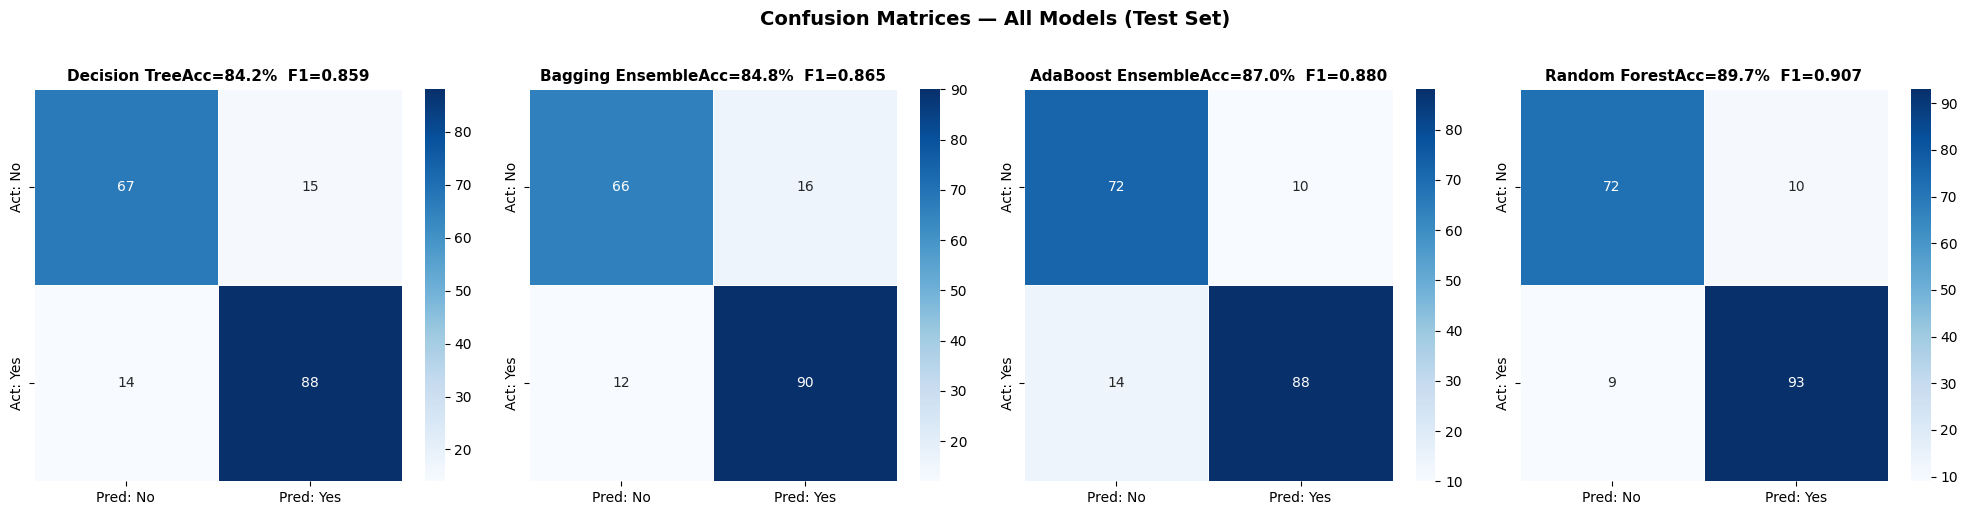

  MOST CONFUSED CLASS ANALYSIS (per-class error rate on Test Set)
Model : Decision Tree
    Class 0 error rate (FP — healthy flagged as sick) :  18.3%  |  FP= 15  out of  82 actual No
    Class 1 error rate (FN — sick cleared as healthy) :  13.7%  |  FN= 14  out of 102 actual Yes
    ► Most confused class : No Heart Disease (Class 0)
Model : Bagging Ensemble
    Class 0 error rate (FP — healthy flagged as sick) :  19.5%  |  FP= 16  out of  82 actual No
    Class 1 error rate (FN — sick cleared as healthy) :  11.8%  |  FN= 12  out of 102 actual Yes
    ► Most confused class : No Heart Disease (Class 0)
Model : AdaBoost Ensemble
    Class 0 error rate (FP — healthy flagged as sick) :  12.2%  |  FP= 10  out of  82 actual No
    Class 1 error rate (FN — sick cleared as healthy) :  13.7%  |  FN= 14  out of 102 actual Yes
    ► Most confused class : Heart Disease    (Class 1)
Model : Random Forest
    Class 0 error rate (FP — healthy flagged as sick) :  12.2%  |  FP= 10  out of  82 actual No

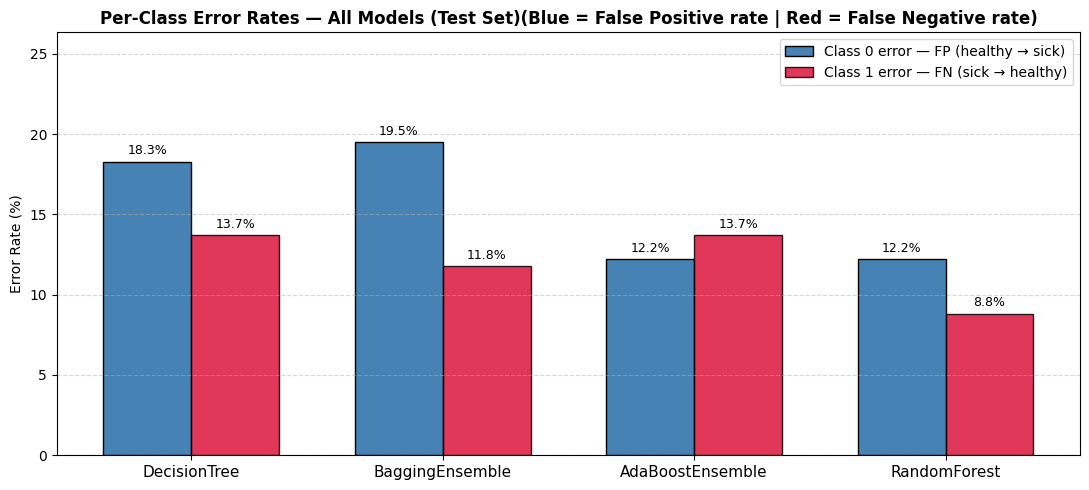

In [ ]:
# Confusion Matrices — All 4 Models 
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_info = [
    ('Decision Tree',     y_pred_dt,  axes[0]),
    ('Bagging Ensemble',  y_pred_bag, axes[1]),
    ('AdaBoost Ensemble', y_pred_ada, axes[2]),
    ('Random Forest',     y_pred_rf,  axes[3]),
]

for name, preds, ax in models_info:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Act: No',  'Act: Yes'],
                linewidths=0.5)
    acc_v = accuracy_score(y_test, preds)
    f1_v  = f1_score(y_test, preds, average='binary')
    ax.set_title(f'{name}Acc={acc_v*100:.1f}%  F1={f1_v:.3f}',
                 fontsize=11, fontweight='bold')

fig.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Most Confused Class Analysis — All 4 Models 
print('' + '='*70)
print('  MOST CONFUSED CLASS ANALYSIS (per-class error rate on Test Set)')
print('='*70)

label_names = {0: 'No Heart Disease (Class 0)', 1: 'Heart Disease    (Class 1)'}

confusion_summary = []

for name, preds in [('Decision Tree',     y_pred_dt),
                    ('Bagging Ensemble',  y_pred_bag),
                    ('AdaBoost Ensemble', y_pred_ada),
                    ('Random Forest',     y_pred_rf)]:
    cm = confusion_matrix(y_test, preds)

    # Per-class error rate = off-diagonal / total actual for that class
    err_class0 = cm[0, 1] / cm[0].sum()   # FP rate  (healthy → sick)
    err_class1 = cm[1, 0] / cm[1].sum()   # FN rate  (sick → healthy)

    most_confused = 0 if err_class0 > err_class1 else 1
    confusion_summary.append({
        'model':          name,
        'err_class0':     err_class0,
        'err_class1':     err_class1,
        'most_confused':  most_confused,
    })

    print(f'Model : {name}')
    print(f'    Class 0 error rate (FP — healthy flagged as sick) : {err_class0*100:5.1f}%  |  FP={cm[0,1]:>3d}  out of {cm[0].sum():>3d} actual No')
    print(f'    Class 1 error rate (FN — sick cleared as healthy) : {err_class1*100:5.1f}%  |  FN={cm[1,0]:>3d}  out of {cm[1].sum():>3d} actual Yes')
    print(f'    ► Most confused class : {label_names[most_confused]}')

print('' + '='*70)


# Bar Chart: Per-Class Error Rates
model_names_short = ['DecisionTree', 'BaggingEnsemble',
                     'AdaBoostEnsemble', 'RandomForest']
err0 = [s['err_class0'] * 100 for s in confusion_summary]
err1 = [s['err_class1'] * 100 for s in confusion_summary]

x  = np.arange(len(model_names_short))
w  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars0 = ax.bar(x - w/2, err0, w, label='Class 0 error — FP (healthy → sick)',
               color='steelblue', edgecolor='black')
bars1 = ax.bar(x + w/2, err1, w, label='Class 1 error — FN (sick → healthy)',
               color='crimson',   edgecolor='black', alpha=0.85)

for bar in list(bars0) + list(bars1):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names_short, fontsize=11)
ax.set_ylabel('Error Rate (%)')
ax.set_title('Per-Class Error Rates — All Models (Test Set)'
             '(Blue = False Positive rate | Red = False Negative rate)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(err0), max(err1)) * 1.35)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
